# **01: Distillation of Vision Models on CIFAR10**

This notebooks will illustrate how to do the following:
* Use `HintonLoss` for knowledge distillation at the logits level, with a theorical explanation
* Use the `FeatureLoss` for knowledge distillation at intermediate levels, with a theorical explanation
* Combine these 2 losses into one with `CombinedLoss`

The use case example would be the CIFAR10, a benchmark dataset of 60,000 color images sized 32 × 32 pixels, divided evenly into 10 distinct object classes. The goal here is not to reach state-of-the-art performance but to show how to use `shrinkai` effectively for knowledge distillation.

In [2]:
import torch
import tutorial_utils
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

from shrinkai.distillation import Distiller

In [2]:
teacher = torch.hub.load(
    "chenyaofo/pytorch-cifar-models",
    "cifar10_vgg19_bn",
    pretrained=True,
    verbose=False,
)

student = torch.hub.load(
    "chenyaofo/pytorch-cifar-models",
    "cifar10_resnet20",
    pretrained=False,
    verbose=False,
)

In [3]:
def build_cifar_dataloaders(
    batch_size: int = 64,
    subset_size: int | None = 3000,
) -> tuple[DataLoader, DataLoader, torch.Tensor]:
    transform_train = transforms.Compose(
        [
            transforms.RandomCrop(32, padding=4),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
        ]
    )

    transform_val = transforms.Compose(
        [
            transforms.ToTensor(),
            transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
        ]
    )

    train_dataset = datasets.CIFAR10(
        root="./data", train=True, download=True, transform=transform_train
    )
    val_dataset = datasets.CIFAR10(
        root="./data", train=False, download=True, transform=transform_val
    )

    if subset_size is not None:
        train_dataset = Subset(train_dataset, range(min(subset_size, len(train_dataset))))
        val_dataset = Subset(val_dataset, range(min(subset_size // 4, len(val_dataset))))

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

    sample_input = torch.randn(batch_size, 3, 32, 32)

    return train_loader, val_loader, sample_input

In [4]:
train_loader, val_loader, sample_input = build_cifar_dataloaders(batch_size=128, subset_size=None)

To distill models using `shrinkai`, you only need to use a `DistillationPipeline` with your 2 models, training parameters and a `BaseDistillationLoss` object. The package provides many Loss functions, but you can create your own.

## **Hinton Loss**

In [4]:
from shrinkai.distillation.losses import HintonLoss

Hinton Loss is the most common Loss for distillation, and was introduced in the paper *Distilling the Knowledge in a Neural Network* in 2015:

$$L_{hinton}\left(z_{student}, z_{teacher}, y_{true}\right) = \left(1 - \alpha\right) L_{CE}\left(z_{student}, y_{true}\right) + \alpha \cdot T^2 \cdot L_{KL}\left(\text{softmax}\left(\frac{z_{student}}{T}\right), \text{softmax}\left(\frac{z_{teacher}}{T}\right)\right)$$

with:

* **$z_{student}$**: The logits output by the student model.
* **$z_{teacher}$**: The logits output by the larger, pre-trained teacher model.
* **$y_{true}$**: The ground-truth labels from the actual dataset.
* **$L_{CE}$**: The standard Cross-Entropy loss function.
* **$L_{KL}$**: The Kullback-Leibler Divergence loss. Measures the distance between the student's soft probability distribution and the teacher's soft probability distribution. 
* **$\alpha$**: A hyperparameter between 0 and 1 that balances the two losses. Bigger $\alpha$ means teacher's logits are more important than ground truth. 
* **$T$ (temperature)**: A hyperparameter used to divide the logits before the softmax function. A higher temperature "softens" the probabilities, revealing the secondary class relationships ("dark knowledge") learned by the teacher. Dividing by $T$ shrinks the gradients by $1/T^2$, so the distillation loss must be multiplied by $T^2$ to keep it balanced with the standard cross-entropy loss.

This Loss function allows the student to learn from the teacher reponses but also from the ground truth (depending on $\alpha$). However, it limits the distillation strictly to the final logits, it does not allow the student to learn from the teacher's intermediate hidden states or feature maps.

In [5]:
hinton_loss = HintonLoss(temperature=4.0, alpha=0.7)

In [ ]:
distiller = Distiller(
    teacher=teacher,
    student=student,
    criterion=hinton_loss,
    optimizer="adamw",
    lr=5e-4,
    weight_decay=1e-4,
    device="auto",
)

In [7]:
training_history = distiller.fit(
    train_dataloader=train_loader,
    val_dataloader=val_loader,
    epochs=15,
)

Epoch [01/15] Train Loss: 7.9959 - Train Acc: 40.59% | Val Loss: 6.5350 - Val Acc: 47.57%


Epoch [02/15] Train Loss: 6.0768 - Train Acc: 55.75% | Val Loss: 4.8902 - Val Acc: 60.99%


Epoch [03/15] Train Loss: 5.2876 - Train Acc: 61.73% | Val Loss: 4.4997 - Val Acc: 63.26%


Epoch [04/15] Train Loss: 4.7830 - Train Acc: 65.55% | Val Loss: 4.3764 - Val Acc: 64.93%


Epoch [05/15] Train Loss: 4.3449 - Train Acc: 68.81% | Val Loss: 3.9684 - Val Acc: 67.77%


...

Epoch [11/15] Train Loss: 3.0063 - Train Acc: 78.80% | Val Loss: 2.8451 - Val Acc: 76.77%


Epoch [12/15] Train Loss: 2.8809 - Train Acc: 79.74% | Val Loss: 2.9715 - Val Acc: 75.95%


Epoch [13/15] Train Loss: 2.7832 - Train Acc: 80.41% | Val Loss: 2.5814 - Val Acc: 78.56%


Epoch [14/15] Train Loss: 2.6852 - Train Acc: 81.30% | Val Loss: 2.6016 - Val Acc: 78.88%


Epoch [15/15] Train Loss: 2.5990 - Train Acc: 81.85% | Val Loss: 2.6917 - Val Acc: 77.92%


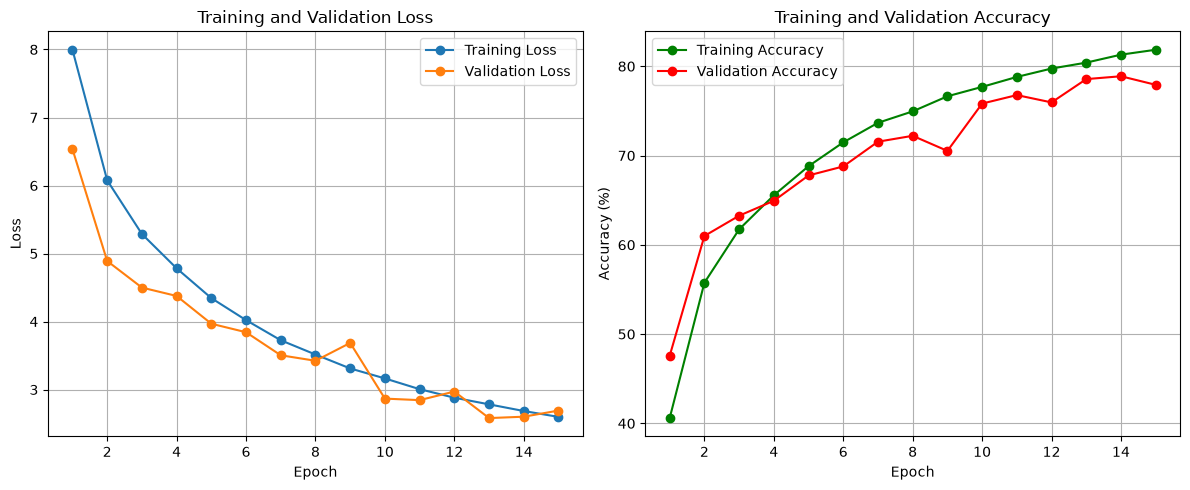

In [8]:
tutorial_utils.plot_history(training_history)

The student model has been trained on a small number of epochs to avoid the training to be too long. It seems that it has not reached the best performance yet, but it is not the goal here. As the training is over, a small report can be displayed and the student model can be saved:

In [9]:
report = distiller.benchmark(
    sample_input=sample_input,
    teacher_name="ViT-Tiny (CIFAR-10)",
    student_name="ResNet-18 (Distilled)",
    val_dataloader=val_loader,
)

report.show()

                                         Distillation Benchmark Report                                          
┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Metric            ┃ Teacher (ViT-Tiny (CIFAR-10)) ┃ Student (ResNet-18 (Distilled)) ┃     Gain / Compression ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Parameters        │                       20.57 M │                          0.27 M │                 -98.7% │
│ Model Size (Disk) │                      78.53 MB │                         1.08 MB │ -98.6% (72.7x smaller) │
│ Latency / Sample  │                       0.29 ms │                         0.05 ms │            6.3x faster │
│ Throughput (FPS)  │                  3478.6 img/s │                   21923.8 img/s │    +6.3x (21923.8 FPS) │
│ Accuracy          │                        93.39% │                          77.92% │         83.4% retained │
└───────────────────┴───────────────────────────────┴─────────────────────────────────┴────────────────────────┘

In [ ]:
output_path = "../../models/tutorial_01_hinton.pt"
distiller.save_student(output_path)

## **Feature Loss**

In [6]:
from shrinkai.adapters import FeatureExtractor, FeatureProjector
from shrinkai.distillation.losses import FeatureLoss, ProjectedFeatureLoss

While Hinton Loss focuses on the final output, Feature-Based Distillation forces the student to mimic the internal reasoning process of the teacher. Introduced in the paper *FitNets: Hints for Thin Deep Nets* (2014), this approach aligns the intermediate hidden states (or feature maps) of the two models.

$$L_{feature}\left(f_{student}, f_{teacher}\right) = \text{Distance}\left(P(f_{student}), f_{teacher}\right)$$

with:

* **$f_{student}$**: The intermediate feature map extracted from a specific layer of the student model.
* **$f_{teacher}$**: The intermediate feature map extracted from a specific layer of the teacher model.
* **$P$ (Projector)**: A transformation function (usually a 1x1 Convolution or a Linear layer) applied to the student's features. Because the student is often smaller, its feature maps have fewer channels than the teacher's. The projector aligns the student's dimensions with the teacher's dimensions.
* **$\text{Distance}$**: The metric used to compute the difference between the two feature maps (e.g., Mean Squared Error, L1, or Cosine Similarity). 

This Loss function allows the student to learn hierarchical representations and rich spatial or semantic features directly from the teacher. It is especially powerful when the teacher is much deeper than the student. However, performing Knowledge Distillation at intermediate levels (hidden features, attention maps) is far more challenging than standard logit distillation. Because the student and teacher often have completely different architectures, their internal states are not only difficult to extract, but they also have mismatched channel dimensions and layer names.

To solve this elegantly, `shrinkai` provides 3 dedicated classes:

* `FeatureExtractor`: Dynamically intercepts intermediate activations during the forward pass (without modifying the original models' source code).
* `FeatureProjector`: Aligns the student's feature dimensions with the teacher's using projection layers (the $P$ function in the equation above).
* `ProjectedFeatureLoss`: A seamless bridge that orchestrates the extractor, the projector, and your chosen feature loss into a single criterion ready for training.

To get your neural network architecture, you can use the following lines.

In [5]:
print(dict(teacher.named_modules()).keys())

dict_keys(['', 'features', 'features.0', 'features.1', 'features.2', 'features.3', 'features.4', 'features.5', 'features.6', 'features.7', 'features.8', 'features.9', 'features.10', 'features.11', 'features.12', 'features.13', 'features.14', 'features.15', 'features.16', 'features.17', 'features.18', 'features.19', 'features.20', 'features.21', 'features.22', 'features.23', 'features.24', 'features.25', 'features.26', 'features.27', 'features.28', 'features.29', 'features.30', 'features.31', 'features.32', 'features.33', 'features.34', 'features.35', 'features.36', 'features.37', 'features.38', 'features.39', 'features.40', 'features.41', 'features.42', 'features.43', 'features.44', 'features.45', 'features.46', 'features.47', 'features.48', 'features.49', 'features.50', 'features.51', 'features.52', 'classifier', 'classifier.0', 'classifier.1', 'classifier.2', 'classifier.3', 'classifier.4', 'classifier.5', 'classifier.6'])


In [6]:
print(dict(student.named_modules()).keys())

dict_keys(['', 'conv1', 'bn1', 'relu', 'layer1', 'layer1.0', 'layer1.0.conv1', 'layer1.0.bn1', 'layer1.0.relu', 'layer1.0.conv2', 'layer1.0.bn2', 'layer1.1', 'layer1.1.conv1', 'layer1.1.bn1', 'layer1.1.relu', 'layer1.1.conv2', 'layer1.1.bn2', 'layer1.2', 'layer1.2.conv1', 'layer1.2.bn1', 'layer1.2.relu', 'layer1.2.conv2', 'layer1.2.bn2', 'layer2', 'layer2.0', 'layer2.0.conv1', 'layer2.0.bn1', 'layer2.0.relu', 'layer2.0.conv2', 'layer2.0.bn2', 'layer2.0.downsample', 'layer2.0.downsample.0', 'layer2.0.downsample.1', 'layer2.1', 'layer2.1.conv1', 'layer2.1.bn1', 'layer2.1.relu', 'layer2.1.conv2', 'layer2.1.bn2', 'layer2.2', 'layer2.2.conv1', 'layer2.2.bn1', 'layer2.2.relu', 'layer2.2.conv2', 'layer2.2.bn2', 'layer3', 'layer3.0', 'layer3.0.conv1', 'layer3.0.bn1', 'layer3.0.relu', 'layer3.0.conv2', 'layer3.0.bn2', 'layer3.0.downsample', 'layer3.0.downsample.0', 'layer3.0.downsample.1', 'layer3.1', 'layer3.1.conv1', 'layer3.1.bn1', 'layer3.1.relu', 'layer3.1.conv2', 'layer3.1.bn2', 'layer3.2

Before starting the distillation, some configs must be done.

In [7]:
# Make sure these 2 dictionnaries have the same values

teacher_layers = {
    "features.13": "stage_1",
    "features.26": "stage_2",
    "features.39": "stage_3",
}
student_layers = {
    "layer1": "stage_1",
    "layer2": "stage_2",
    "layer3": "stage_3",
}

In [8]:
wrapped_teacher = FeatureExtractor(teacher, target_layers=teacher_layers)
wrapped_student = FeatureExtractor(student, target_layers=student_layers)

In [9]:
# Make sure the keys are the values of the teacher/student_layers
# and that the dimension are right

proj_config = {
    "stage_1": {
        "in_channels": 16,
        "out_channels": 128,
        "type": "conv",
        "use_norm": True,
    },
    "stage_2": {
        "in_channels": 32,
        "out_channels": 256,
        "type": "conv",
        "use_norm": True,
    },
    "stage_3": {
        "in_channels": 64,
        "out_channels": 512,
        "type": "conv",
        "use_norm": True,
    },
}

In [10]:
projector = FeatureProjector(proj_config)

feature_loss = ProjectedFeatureLoss(
    projector=projector, feature_loss=FeatureLoss(loss_type="mse", normalize=True)
)

Now, everything is ready for the distillation.

In [12]:
distiller = Distiller(
    teacher=wrapped_teacher,
    student=wrapped_student,
    criterion=feature_loss,
    optimizer="adamw",
    lr=5e-4,
    weight_decay=1e-4,
    device="auto",
)

In [16]:
training_history = distiller.fit(
    train_dataloader=train_loader,
    val_dataloader=val_loader,
    epochs=15,
)

Epoch [01/15] Train Loss: 0.0002 - Train Acc: 9.62% | Val Loss: 0.0004 - Val Acc: 9.99%


Epoch [02/15] Train Loss: 0.0002 - Train Acc: 9.95% | Val Loss: 0.0003 - Val Acc: 10.02%


Epoch [03/15] Train Loss: 0.0002 - Train Acc: 9.87% | Val Loss: 0.0002 - Val Acc: 9.28%


Epoch [04/15] Train Loss: 0.0002 - Train Acc: 9.75% | Val Loss: 0.0003 - Val Acc: 10.06%


Epoch [05/15] Train Loss: 0.0002 - Train Acc: 10.28% | Val Loss: 0.0003 - Val Acc: 11.53%


...

Epoch [11/15] Train Loss: 0.0001 - Train Acc: 11.20% | Val Loss: 0.0002 - Val Acc: 11.18%


Epoch [12/15] Train Loss: 0.0001 - Train Acc: 10.34% | Val Loss: 0.0002 - Val Acc: 9.77%


Epoch [13/15] Train Loss: 0.0001 - Train Acc: 10.11% | Val Loss: 0.0002 - Val Acc: 9.95%


Epoch [14/15] Train Loss: 0.0001 - Train Acc: 9.86% | Val Loss: 0.0002 - Val Acc: 9.81%


Epoch [15/15] Train Loss: 0.0001 - Train Acc: 9.79% | Val Loss: 0.0002 - Val Acc: 9.70%


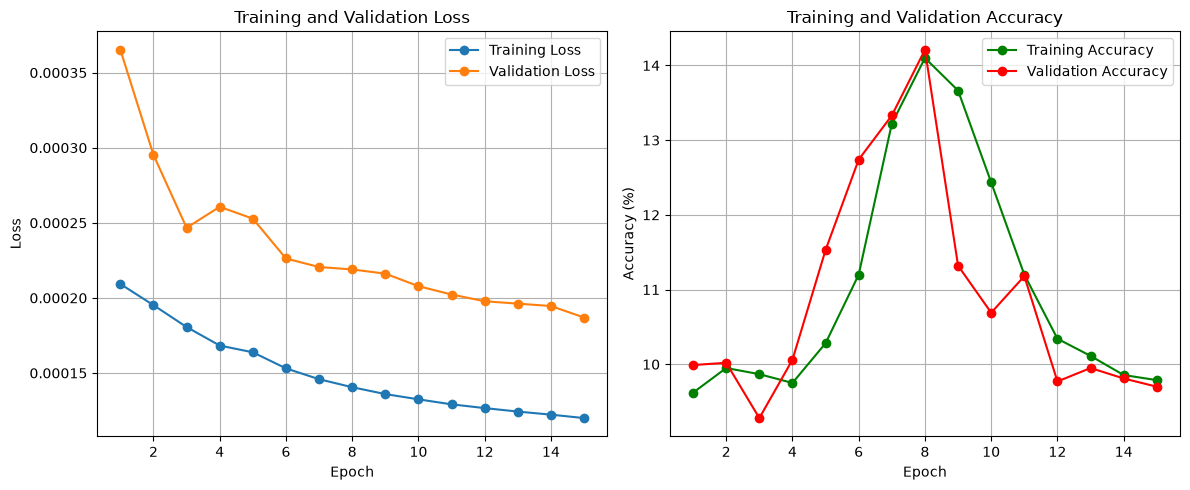

In [17]:
tutorial_utils.plot_history(training_history)

As observed, the accuracy is not stable and remain virtually constant. One could have expected this behavior because `FeatureLoss` exclusively optimizes the intermediate representations (hidden states) rather than the final classification head. As a consequence, the predictive layer remains untrained, resulting in an accuracy of approximately 10%, the exact baseline for random guessing on the CIFAR-10 dataset. 

However, `FeatureLoss` is highly valuable: it forces the student model to capture the deep, representational logic of the teacher. While this structural learning is not directly reflected in standard classification metrics, it builds a robust foundation. To leverage these rich intermediate features while actually training the model to predict correctly, combining feature-based and logit-based losses becomes essential.

By the way, the `feature_analysis` method from `Distiller`, as `benchmark`, gives important metrics to evaluate how well the student has learned from the teacher for each feature. So far, there are 3 metrics:

* **CKA (Centered Kernel Alignment)**: Measures the absolute similarity between the two feature spaces using their Gram matrices ($K$ for teacher, $L$ for student, just like in the original paper). 
  $$CKA(K, L) = \frac{HSIC(K, L)}{\sqrt{HSIC(K, K) HSIC(L, L)}}$$
  * HSIC is the Hilbert-Schmidt Independence Criterion.
  * Range: $[0, 1]$
  * Interpretation: A score close to 1 indicates that both models extract highly correlated linear features.

* **RSA (Representational Similarity Analysis)**: Measures the topological geometry of the features by comparing the pairwise distances between tokens in a batch using Pearson correlation ($\rho$). Let $R_S$ and $R_T$ be the Representational Dissimilarity Matrices (RDMs) of the student and teacher.
  $$RSA = \frac{\text{cov}(R_S, R_T)}{\sigma_{R_S} \sigma_{R_T}}$$
  * Range: $[-1, 1]$
  * Interpretation: A high positive score means that if the teacher considers two words to be contextually similar, the student does too.

* **Spatial Attention**: Computes the direct spatial overlap of the attention maps (typically via Cosine Similarity). 
  $$Spatial = \frac{\sum (A_{student} \odot A_{teacher})}{\|A_{student}\| \|A_{teacher}\|}$$
  * **Range**: $[0, 1]$ 
  * **Interpretation**: It answers the question: *"Are they looking at the same words?"*. A score of ~0.78 means that when the teacher focuses its attention weights heavily on a sentiment-carrying word like "terrible", the student accurately replicates this exact visual focus, ignoring irrelevant connecting words.

In [ ]:
analysis_report = distiller.feature_analysis(val_loader, metrics=["cka", "rsa", "attention"])
analysis_report.show()

          Representation Alignment Report (Feature Distillation)          
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer / Stage Alias ┃ CKA (Linear) ┃ RSA (Pearson) ┃ Spatial Attention ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ stage_1             │        0.401 │         0.377 │             0.940 │
│ stage_2             │        0.387 │         0.506 │             0.934 │
│ stage_3             │        0.397 │         0.565 │             0.985 │
└─────────────────────┴──────────────┴───────────────┴───────────────────┘

## **Hybrid Loss**

In [11]:
from shrinkai.distillation.losses import HybridLoss

`HybridLoss` aims to use a Loss on logits and a Loss on hidden states. Here are the 2 ways to use it:
* **Convex**: $L = L_{logits} + \text{weight} \times L_{features}$
* **Additive**: $L = (1 - \text{weight}) \times L_{logits} + \text{weight} \times L_{features}$

For this tutorial, let's just add the 2 previous Losses with a `feature_weight` equals to 1000 in order to have 2 terms with the same scale, according to the previous trainings.

In [12]:
hybrid_loss = HybridLoss(
    logit_loss=hinton_loss,
    feature_loss=feature_loss,
    feature_weight=1000,
    convex_weighting=False,
)

In [13]:
distiller = Distiller(
    teacher=wrapped_teacher,
    student=wrapped_student,
    criterion=hybrid_loss,
    optimizer="adamw",
    lr=5e-4,
    weight_decay=1e-4,
    device="auto",
)

In [14]:
training_history = distiller.fit(
    train_dataloader=train_loader,
    val_dataloader=val_loader,
    epochs=15,
)

Epoch [01/15] Train Loss: 8.6162 - Train Acc: 39.01% | Val Loss: 6.7268 - Val Acc: 48.03%


Epoch [02/15] Train Loss: 6.7367 - Train Acc: 52.89% | Val Loss: 6.0808 - Val Acc: 52.61%


Epoch [03/15] Train Loss: 5.7613 - Train Acc: 60.05% | Val Loss: 4.9509 - Val Acc: 61.98%


Epoch [04/15] Train Loss: 5.1671 - Train Acc: 64.38% | Val Loss: 4.8846 - Val Acc: 62.19%


Epoch [05/15] Train Loss: 4.7220 - Train Acc: 67.39% | Val Loss: 4.2583 - Val Acc: 66.67%


...

Epoch [11/15] Train Loss: 3.3055 - Train Acc: 77.73% | Val Loss: 3.0718 - Val Acc: 75.76%


Epoch [12/15] Train Loss: 3.1584 - Train Acc: 79.00% | Val Loss: 2.9652 - Val Acc: 76.46%


Epoch [13/15] Train Loss: 3.0429 - Train Acc: 79.74% | Val Loss: 2.7350 - Val Acc: 78.30%


Epoch [14/15] Train Loss: 2.9351 - Train Acc: 80.55% | Val Loss: 2.7440 - Val Acc: 78.51%


Epoch [15/15] Train Loss: 2.8368 - Train Acc: 81.17% | Val Loss: 2.8931 - Val Acc: 77.15%


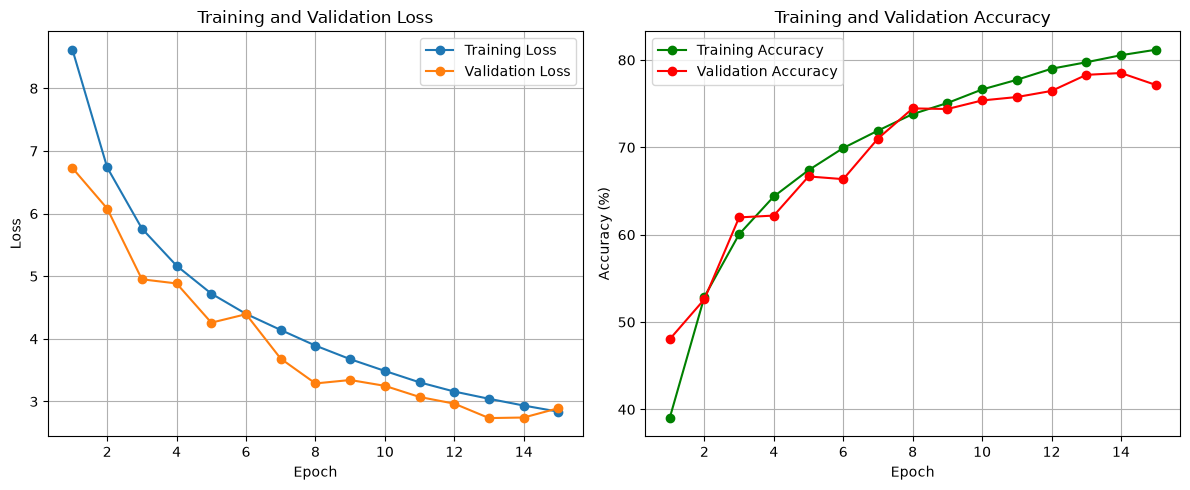

In [15]:
tutorial_utils.plot_history(training_history)

In [16]:
distiller.benchmark(
    sample_input=sample_input,
    teacher_name="ViT-Tiny (CIFAR-10)",
    student_name="ResNet-18 (Distilled)",
    val_dataloader=val_loader,
).show()

                                         Distillation Benchmark Report                                          
┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Metric            ┃ Teacher (ViT-Tiny (CIFAR-10)) ┃ Student (ResNet-18 (Distilled)) ┃     Gain / Compression ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Parameters        │                       20.57 M │                          0.27 M │                 -98.7% │
│ Model Size (Disk) │                      78.53 MB │                         1.08 MB │ -98.6% (72.7x smaller) │
│ Latency / Sample  │                       0.29 ms │                         0.05 ms │            5.6x faster │
│ Throughput (FPS)  │                  3455.3 img/s │                   19430.3 img/s │    +5.6x (19430.3 FPS) │
│ Accuracy          │                        93.39% │                          77.15% │         82.6% retained │
└───────────────────┴───────────────────────────────┴─────────────────────────────────┴────────────────────────┘

In [ ]:
distiller.feature_analysis(val_loader, metrics=["cka", "rsa", "attention"]).show()

          Representation Alignment Report (Feature Distillation)          
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer / Stage Alias ┃ CKA (Linear) ┃ RSA (Pearson) ┃ Spatial Attention ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ stage_1             │        0.888 │         0.483 │             0.955 │
│ stage_3             │        0.694 │         0.619 │             0.981 │
│ stage_2             │        0.628 │         0.427 │             0.885 │
└─────────────────────┴──────────────┴───────────────┴───────────────────┘

In this example, combining both a logit Loss and a feature Loss has offered better results and better deep comprehension of the data in the hidden layers. 

## **References**

1. Hinton, G., Vinyals, O., & Dean, J. (2015). *Distilling the Knowledge in a Neural Network*. arXiv:1503.02531.  
   https://arxiv.org/abs/1503.02531

2. Romero, A., Ballas, N., Ebrahimi Kahou, S., Chassang, A., Gatta, C., & Bengio, Y. (2015). *FitNets: Hints for Thin Deep Nets*. ICLR. arXiv:1412.6550.  
   https://arxiv.org/abs/1412.6550

3. Zagoruyko, S., & Komodakis, N. (2017). *Paying More Attention to Attention: Improving the Performance of Convolutional Neural Networks via Attention Transfer*. ICLR. arXiv:1612.03928.  
   https://arxiv.org/abs/1612.03928

4. Kornblith, S., Norouzi, M., Lee, H., & Hinton, G. (2019). *Similarity of Neural Network Representations Revisited*. ICML, PMLR 97, 3519–3529. arXiv:1905.00414.  
   https://arxiv.org/abs/1905.00414

5. Gretton, A., Bousquet, O., Smola, A., & Schölkopf, B. (2005). *Measuring Statistical Dependence with Hilbert-Schmidt Norms*. ALT 2005, pp. 63–77.  
   DOI: 10.1007/11564089_7

6. Kriegeskorte, N., Mur, M., & Bandettini, P. (2008). *Representational Similarity Analysis – Connecting the Branches of Systems Neuroscience*. Frontiers in Systems Neuroscience, 2, 4.  
   DOI: 10.3389/neuro.06.004.2008

7. Krizhevsky, A. (2009). *Learning Multiple Layers of Features from Tiny Images*. Technical Report, University of Toronto.